# Импрорты и нужные классы

In [1]:
import sys
import os
from dotenv import load_dotenv
import torch
sys.path.append('..')
env_file = os.path.join('..', '.env')
load_dotenv(env_file)
name_dataset = os.environ['NAME_DATASET']
name_test_dataset = os.environ['NAME_TEST_DATASET']
dataset_path = os.environ['DATASET_PATH']
test_path = os.environ['TEST_PATH']
test_coco_path = os.environ['TEST_COCO_PATH']
coco_path = os.environ['COCO_PATH']
cache_pdf = os.environ['CASH_PDF_PATH']

In [2]:
from rows2regionsGLAM.utils.pdf_manager import PDFManager
from rows2regionsGLAM.utils.loger import Loger
from rows2regionsGLAM.utils.row_manager import RowManager
from rows2regionsGLAM.utils.ploter import Ploter
from rows2regionsGLAM.utils.trainer import Trainer
from rows2regionsGLAM.utils.tester import Tester
from rows2regionsGLAM.tokenizers import RowGLAMTokenizer
from rows2regionsGLAM.converters import Rows2Regions
from rows2regionsGLAM.utils.coco_manager import COCOManager
from rows2regionsGLAM.datasetloaders.base_line_dataset import GLAMDataset
from rows2regionsGLAM.models.rowGLAM import TagModule, NodeGLAM, EdgeGLAM, CustomLoss, TorchModel

/home/roma/work/PageR/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
loger = Loger('log.txt')
pdf_manager = PDFManager(conf={"loger": loger, "pdf_reader": "PDFMiner"})
row_manager = RowManager(conf={"loger": loger, "add_image": True})
coco_manager = COCOManager(conf={"loger": loger, "coco_path": coco_path})
ploter = Ploter(conf={"loger": loger})
tokenizer = RowGLAMTokenizer()
loger(tokenizer.get_name())

# Проверка чтения файла

In [4]:
test_file = os.path.join('..', 'test_files', 'PMC5837730_00000.pdf')
# pdf_json = pdf_manager.get_json_from_pdf(test_file, num_page=0)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(test_file, num_page=0)

In [5]:
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

In [6]:
torch_dict = tokenizer(row_json)

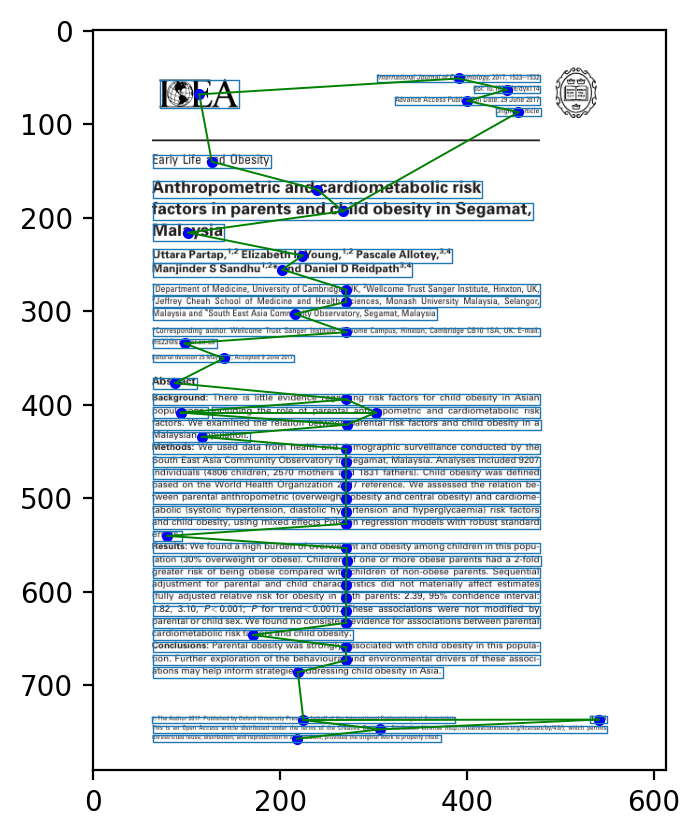

In [7]:
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
# ploter.plot_rows(row_json)
ploter.plot_tokens(tokenizer, torch_dict)

In [8]:
json_true_regions, CLASSES = coco_manager.get_regions_from_json()

In [9]:
CLASSES[3] = "text"
CLASSES

{1: 'text', 2: 'title', 3: 'text', 4: 'table', 5: 'figure', 0: 'other'}

In [10]:
file_names = list(json_true_regions.keys())
file_names.sort()

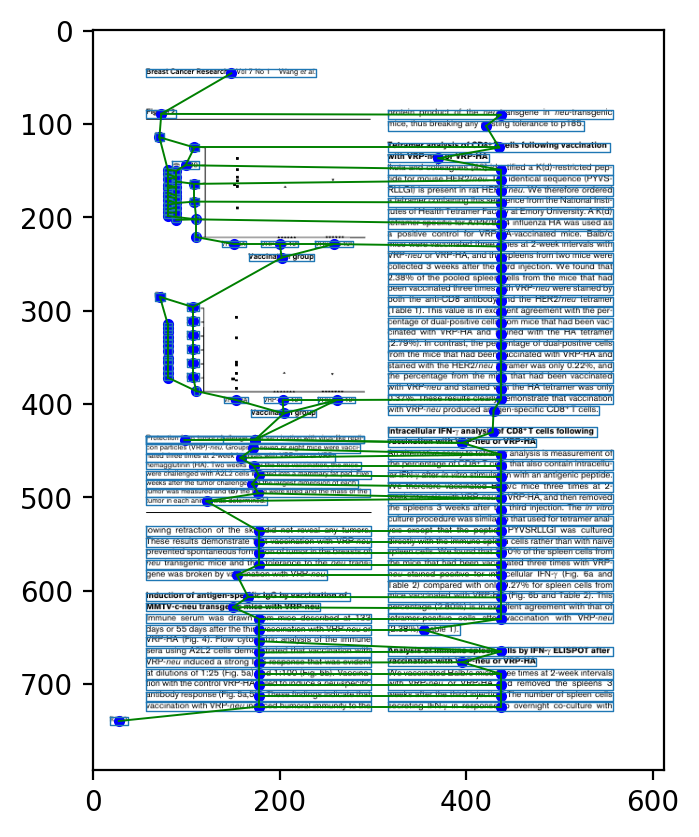

In [11]:
num_file = 1
file_name = file_names[num_file]
dataset_file = os.path.join(dataset_path, file_name)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(dataset_file, num_page=0)
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
torch_dict = tokenizer(row_json)
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
ploter.plot_tokens(tokenizer, torch_dict)

# Сохранение датасета

In [12]:
from pager.page_model.sub_models.dtype import ImageSegment


def get_true_edges(token, rows, region_segs, region_categories):
    def is_one_region(row_seg_1, row_seg_2, region_segs):
        for i, reg in enumerate(region_segs):
            if reg.is_intersection(row_seg_1):
                if reg.is_intersection(row_seg_2):
                    return 1
                else:
                    return 0
        return 0

    def get_category(seg, region_segs, region_categories):
        for r, c in zip(region_segs, region_categories):
            if seg.is_intersection(r):
                return c
        return None

    def get_mini_seg(r):
        img_seg = ImageSegment(dict_2p=r)
        if img_seg.height < 5:
            return img_seg
        delta =  int(img_seg.height/5)
        img_seg.y_bottom_right = img_seg.y_bottom_right - delta
        img_seg.y_top_left = img_seg.y_top_left + delta
        return img_seg
    row_segments = [get_mini_seg(row['segment']) for row in rows]
    A = token['inds']
    true_edges = [is_one_region(row_segments[i], row_segments[j], region_segs) for i, j in zip(A[0], A[1])]
    true_nodes = [get_category(row_seg, region_segs, region_categories) for row_seg in row_segments]
    return true_edges, true_nodes

def pdf2torch_dict(path_pdf, coco_dict_file):
        try:
            pdf_json = pdf_manager.get_json_from_pdf(path_pdf, num_page=0)
            w, h = pdf_json['width'],pdf_json['height']
            row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
        except:
            print(path_pdf, '\n')
            return {}
        torch_dict = tokenizer(row_json)
        if name_dataset == "doclaynet":
            coef_w, coef_h = w/1024, h/1024
        elif name_dataset == "publaynet":
            coef_w, coef_h = 1, 1
        coco_dict_file['regions'] = [r for r in coco_dict_file['regions'] if r['segment']['height'] > 0]
        reg_segments = [ImageSegment(dict_p_size={
            "x_top_left": int(r['segment']['x_top_left']*coef_w),
            "y_top_left": int(r['segment']['y_top_left']*coef_h),
            "width": int(r['segment']['width']*coef_w),
            "height": int(r['segment']['height']*coef_h)}) for r in coco_dict_file['regions']]
        reg_categories = [r['category_id'] for r in coco_dict_file['regions']]
        true_edges, true_nodes = get_true_edges(torch_dict, row_json, reg_segments, reg_categories)
        
        del torch_dict['sp_A']
        torch_dict['true_edges'] = true_edges
        torch_dict['true_nodes'] = true_nodes

        return torch_dict
         
        print(f"{(i+1)/N*100:4.2f} %", end='\r')

dataset = GLAMDataset({
    "loger": loger,
    "pdf_dir": dataset_path,
    "coco_file": coco_path,
    "count_class": len(CLASSES),
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
})

# Создание Cache
N = len(dataset)
for i, d in enumerate(dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

# Отрисовска файла из датасета

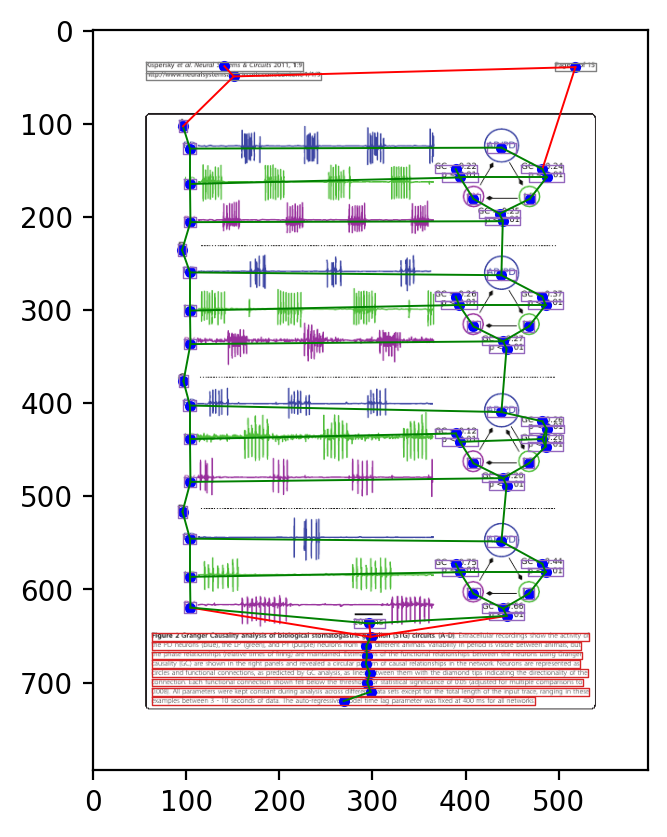

In [13]:
torch_dict2 = dataset[1050]
path_pdf = os.path.join(dataset_path, torch_dict2['file_name'] + ".pdf")
_, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
ploter.plot_tokens(tokenizer, torch_dict2, markup=True)

# Регионы --------------------------------------------------------------
# ann = coco_manager.get_regions_from_json()
# regions = ann[torch_dict2['file_name'] + ".pdf"]['regions']

# for reg in regions:
#     seg = ImageSegment(dict_p_size=reg['segment'])
#     seg.plot()

# Параметры модели

In [14]:
GLAM_MODEL = 'row2region_GLAM_artic'
PARAMS  = {
    "node_featch": 15,
    "edge_featch": 4,
    "epochs": 30,
    "batch_size": 128,
    "learning_rate": 0.001,
    "Tag":[  {'in': -1, 'size': 512, 'out': 512, 'k': 3},
            {'in': 512, 'size': 256, 'out': 256, 'k': 3},
            # {'in': 256, 'size': 128, 'out': 128, 'k': 3},
            # {'in': 64, 'size': 32, 'out': 16, 'k': 3},
            ],
    "NodeLinear": [-1, 64, 32],
    "NodeLinearClassifier": [-1, 16, 8],
    "EdgeLinear": [-1, 16, 4],
    "batchNormNode": True,
    "batchNormEdge": True,
    "seg_k": 0.5,
    "loss_params": {
        "edge_coef": 0.8,
        "node_coef": 0.2,
    },
    "sigmoidEdge": False,
    "NodeClasses": len(CLASSES)
}

In [15]:
# Дисбаланс классов ------------------------------------
import numpy as np
positiv = []
negativ = []

positiv_nodes = []
negativ_nodes = []
k = 0
for g in dataset:
    if not "true_edges" in g or not "true_nodes" in g:
        continue 
    M = len(g['true_edges'])
    p = sum(g['true_edges'])
    n = M - p
    positiv.append(p)
    negativ.append(n)

    M = len(g['true_nodes'])
    nodes = np.array(g['true_nodes'])
    pp = nodes.sum(axis=0)
    if type(pp) is np.float32:
        continue
    nn = M - pp
    
    positiv_nodes.append(pp)
    negativ_nodes.append(nn)
    

P = np.mean(positiv)
N = np.mean(negativ)
PP = np.mean(positiv_nodes, axis=0)
NN = np.mean(negativ_nodes, axis=0)
disb_nodes = NN/PP
disb_nodes[PP == 0.0] = 0
# disb_nodes = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
print(PP)
PARAMS['loss_params']['publaynet_imbalance'] = (disb_nodes/sum(disb_nodes)).tolist()
disb = N/P
print(disb)
PARAMS['loss_params']['edge_imbalance'] = float(disb)
PARAMS

/tmp/ipykernel_171991/3156289910.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  nodes = np.array(g['true_nodes'])


[10.97748   62.375637   2.2818537  3.1362226 38.373135   4.8081274]
0.38261506


{'node_featch': 15,
 'edge_featch': 4,
 'epochs': 30,
 'batch_size': 128,
 'learning_rate': 0.001,
 'Tag': [{'in': -1, 'size': 512, 'out': 512, 'k': 3},
  {'in': 512, 'size': 256, 'out': 256, 'k': 3}],
 'NodeLinear': [-1, 64, 32],
 'NodeLinearClassifier': [-1, 16, 8],
 'EdgeLinear': [-1, 16, 4],
 'batchNormNode': True,
 'batchNormEdge': True,
 'seg_k': 0.5,
 'loss_params': {'edge_coef': 0.8,
  'node_coef': 0.2,
  'publaynet_imbalance': [0.07901868224143982,
   0.007465685252100229,
   0.40992748737335205,
   0.2961258292198181,
   0.017024679109454155,
   0.19043760001659393],
  'edge_imbalance': 0.3826150596141815},
 'sigmoidEdge': False,
 'NodeClasses': 6}

# Обучение модели

In [18]:
model:torch.nn.Module = TorchModel(PARAMS)
total_params = sum(p.numel() for p in model.parameters())  
print(f"Number of parameters: {total_params}") 

Number of parameters: 1473097


In [ ]:
trainer = Trainer(conf={"loger": loger, "params": PARAMS, "model_name": GLAM_MODEL})
trainer.start_train(5, dataset)

# Проверка работы модели

In [16]:
from pager.page_model.sub_models import BaseConverter, RegionModel, RowsModel
PARAMS['sigmoidEdge'] = True
model = TorchModel(PARAMS)
model.load_state_dict(torch.load(GLAM_MODEL, weights_only=True))

rows_model = RowsModel()
region_model = RegionModel()
rows2regions = Rows2Regions({
    'model':model, 
    'tokenizer': RowGLAMTokenizer(),
    'is_merge_extract': True,
    'classes': CLASSES
})

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/utils/_spmm.py:71: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  src = src.to_sparse_csr()
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


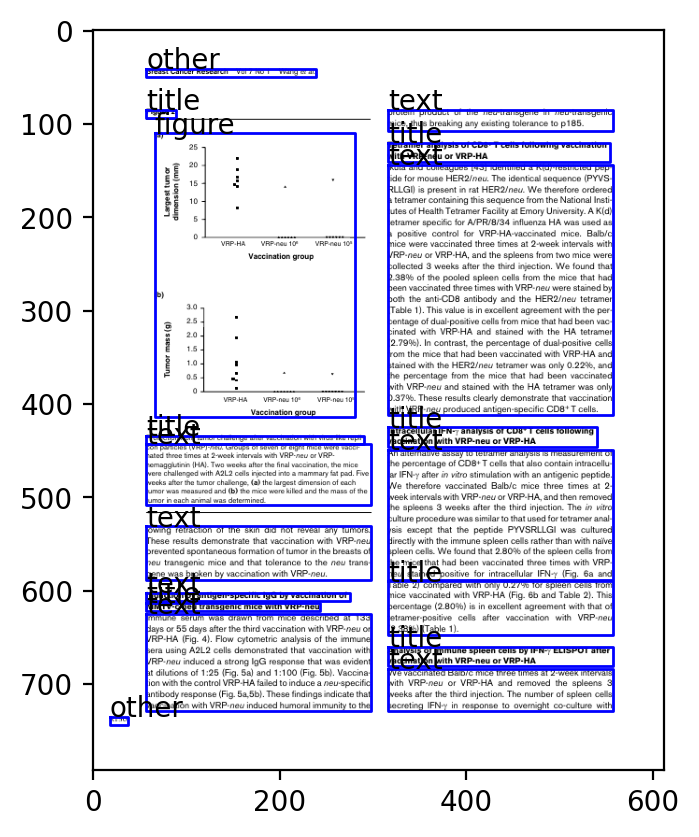

In [17]:
torch_dict2 = dataset[1]
path_pdf = os.path.join(dataset_path, torch_dict2['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict2)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions.convert(rows_model, region_model)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

In [18]:
from rows2regionsGLAM.metrics import GridMetric
from torchmetrics.detection.mean_ap import MeanAveragePrecision

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


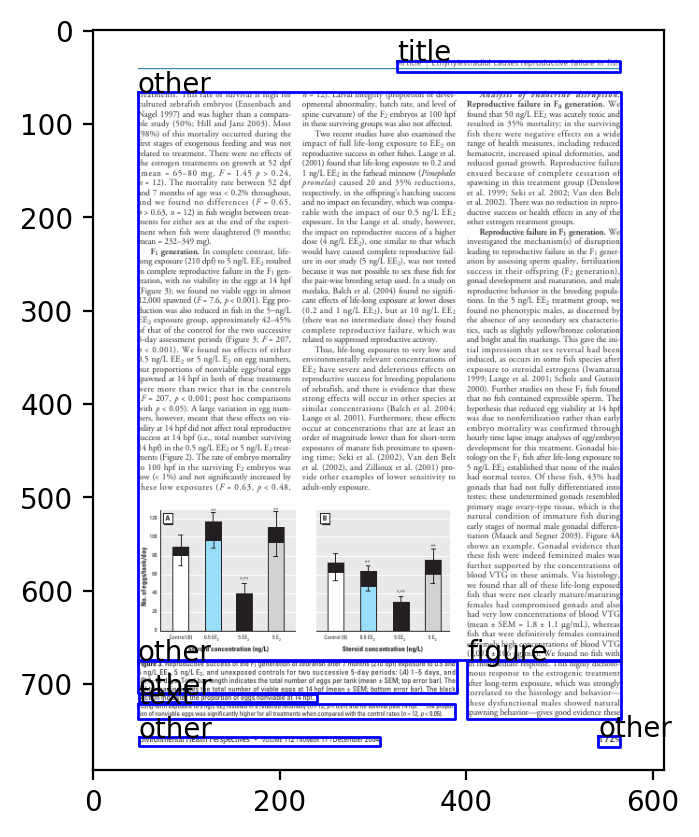

In [19]:
test_dataset = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": test_path,
    "coco_file": test_coco_path,
    "count_class": len(CLASSES),
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
    }
)

torch_dict2 = test_dataset[1]
path_pdf = os.path.join(test_path, torch_dict2['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict2)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions.convert(rows_model, region_model)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

In [20]:
COUNT_TEST_SIZE = 200
loger("Start Test")
loger.time_log()

N = len(test_dataset)
for i, d in enumerate(test_dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

## Оценка

In [ ]:
tester = Tester(conf={
    "loger": loger, 
    "pdf_manager": pdf_manager, 
    "row_manager": row_manager, 
    "rows_model": rows_model, 
    "region_model": region_model, 
    "rows2regions": rows2regions})

target, preds, word_grids, row_grids = tester.calculate_target_and_preds(test_dataset, name_dataset, name_test_dataset, dataset_path, test_path)

Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value


Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P6' is an invalid float value
Cannot set gray non-stroke color because /'P7' is an invalid float value
Cannot set gray non-stroke color because /'P8' is an invalid float value


Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value


In [ ]:
grid_metric = GridMetric()

i = 0
N = len(preds)
for bboxes_pred, bboxes_true, grid_row, grid_word in zip(preds, target, row_grids, word_grids):
    i+=1
    try:
        grid_metric.add_pair(bboxes_pred, bboxes_true, grid_row, grid_word)
        print(f"{(i)/N*100:4.2f} %", end='\r')
    except:
        pass
grid_metric.update()        

In [ ]:
map_metric = MeanAveragePrecision(box_format="xywh")

get_category = lambda an: 1

map_metric.update([dict(     
                    boxes=torch.tensor(bboxes_pred) ,
                    scores=torch.tensor([1.0 for an in bboxes_pred]),
                    labels=torch.tensor([get_category(an) for an in bboxes_pred]),
                    ) for bboxes_pred in preds], 
                  [dict(     
                        boxes=torch.tensor(bboxes_true) ,
                        labels=torch.tensor([get_category(an) for an in bboxes_true]),
                        ) for bboxes_true in target])  
rez = map_metric.compute()
map_metric_rez = f"mAP@IoU[0.50:0.95]   :{rez['map']:.8f}"

In [ ]:
print(map_metric_rez)
print(grid_metric)
loger("Test Result")
loger(map_metric_rez)
loger(grid_metric.__str__())

In [ ]:
mAP@IoU[0.50:0.95]   :0.52044123
==================================================
threshold_05--------------------
precision_row       :0.8745
recall_row          :0.7442
f1_row              :0.8041
precision_word      :0.8312
recall_word         :0.7130
f1_word             :0.7676
threshold_95--------------------
precision_row       :0.7275
recall_row          :0.6222
f1_row              :0.6707
precision_word      :0.6884
recall_word         :0.5949
f1_word             :0.6382